# **1. Perkenalan Dataset**


1. **Sumber Dataset**:  
   Dataset ini berisi berbagai indikator kesehatan dan faktor risiko yang berkaitan dengan penyakit jantung. Parameter seperti usia, jenis kelamin, tekanan darah, kadar kolesterol, kebiasaan merokok, dan pola olahraga telah dikumpulkan untuk menganalisis risiko penyakit jantung dan berkontribusi pada penelitian kesehatan. Dataset ini dapat digunakan oleh para profesional kesehatan, peneliti, dan analis data untuk memeriksa tren yang berkaitan dengan penyakit jantung, mengidentifikasi faktor risiko, dan melakukan berbagai analisis terkait kesehatan.
Sumber:https://www.kaggle.com/datasets/oktayrdeki/heart-disease

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import KNNImputer
import missingno as msno
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from warnings import filterwarnings
warnings.filterwarnings("ignore")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv("heart_disease.csv")
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [3]:
df.shape

(10000, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [5]:
cat_cols = df.select_dtypes(include=["object"]).columns
print("Categorical Columns:", cat_cols)

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Categorical Columns: Index(['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease',
       'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol',
       'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level',
       'Sugar Consumption', 'Heart Disease Status'],
      dtype='object')
Gender: ['Male' 'Female' nan]
Exercise Habits: ['High' 'Low' 'Medium' nan]
Smoking: ['Yes' 'No' nan]
Family Heart Disease: ['Yes' 'No' nan]
Diabetes: ['No' 'Yes' nan]
High Blood Pressure: ['Yes' 'No' nan]
Low HDL Cholesterol: ['Yes' 'No' nan]
High LDL Cholesterol: ['No' 'Yes' nan]
Alcohol Consumption: ['High' 'Medium' 'Low' nan]
Stress Level: ['Medium' 'High' 'Low' nan]
Sugar Consumption: ['Medium' 'Low' 'High' nan]
Heart Disease Status: ['No' 'Yes']


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Buat plot untuk visualisasi data kategorikal

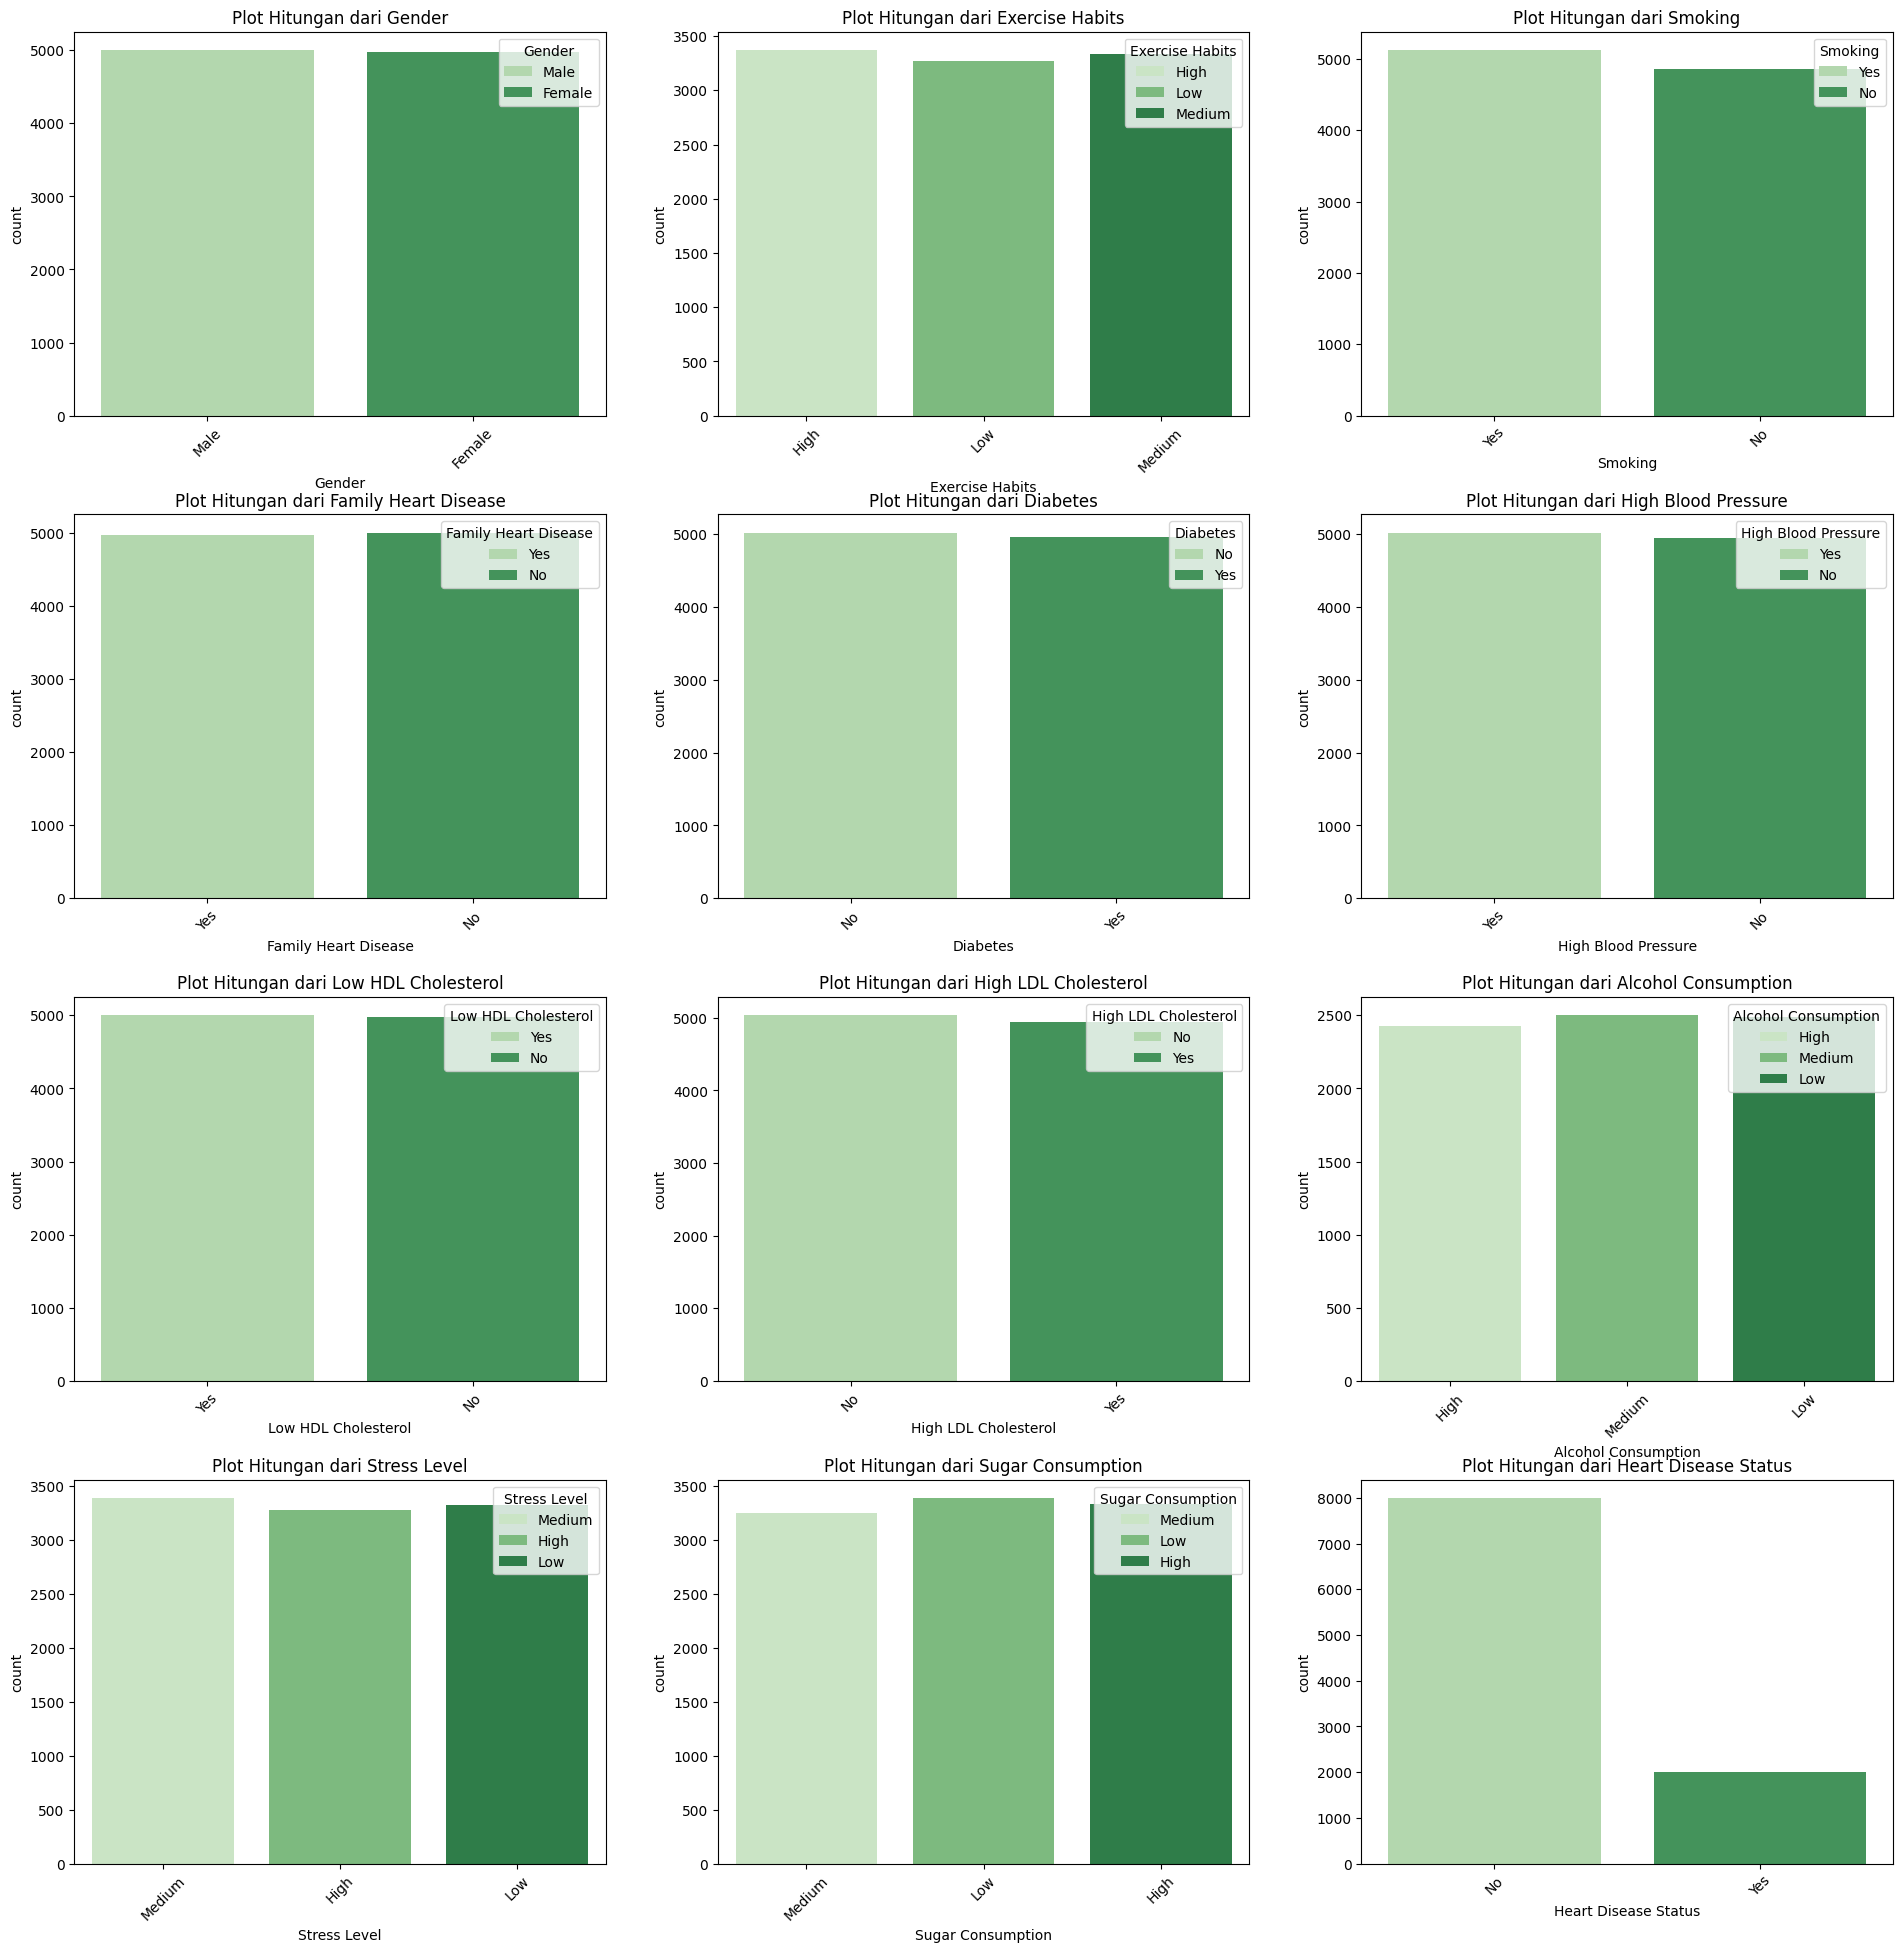

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
fig.tight_layout(pad=5.0)
axes = axes.flatten()

for i, col in enumerate(cat_cols[:12]):
    sns.countplot(x=col, data=df, hue=col, palette='Greens', dodge=False, ax=axes[i])
    axes[i].set_title(f'Plot Hitungan dari {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Sembunyikan subplot yang tidak digunakan
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.show()

Matriks histogram di atas menggambarkan distribusi berbagai faktor terkait kesehatan. Dengan memvisualisasikan distribusi frekuensi setiap fitur, kita dapat mengamati potensi ketidakseimbangan dalam dataset.

Buat boxplot untuk menganalisis distribusi fitur numerik, mengungkap outlier signifikan dan skala fitur yang bervariasi.

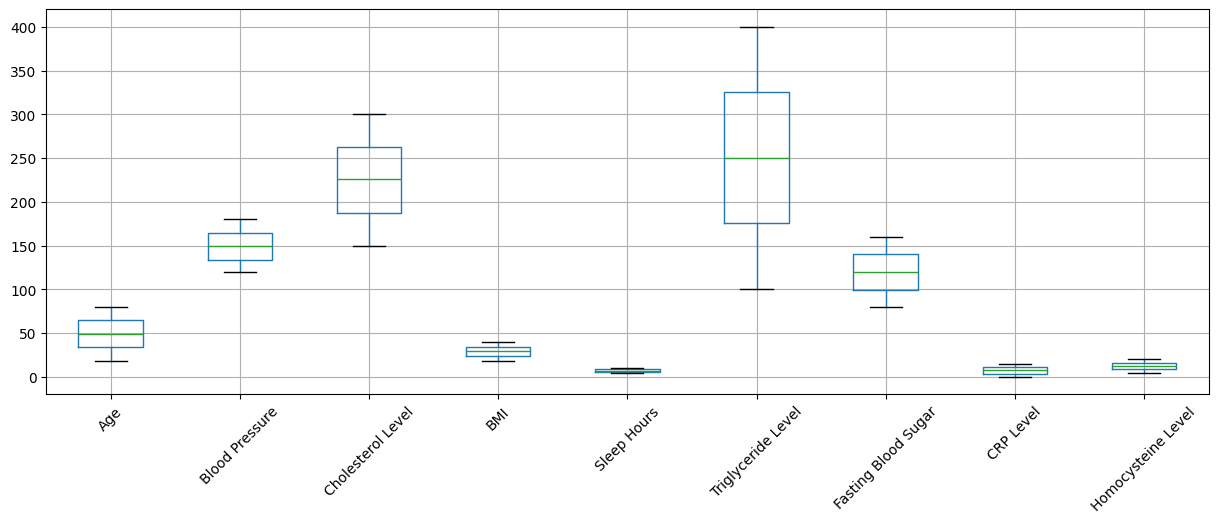

In [7]:
num_cols = df.select_dtypes(include=[ "number" ]).columns
plt.figure(figsize=( 15 ,  5 ))
df[num_cols].boxplot()
plt.xticks(rotation= 45 )
plt.show()

Beberapa atribut, seperti Kadar Trigliserida dan Gula Darah Puasa, memiliki nilai ekstrem yang dapat memengaruhi kinerja model. Perbedaan besar dalam rentang fitur menunjukkan perlunya normalisasi atau standardisasi sebelum pelatihan.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Periksa data yang hilang

In [8]:
df.isna(). sum ()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


Periksa apakah ada duplikat

In [9]:
df.duplicated(). sum ()

np.int64(0)

Mengkodekan 12 variabel kategorikal (tipe objek) sebagai variabel numerik.

In [10]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=['object']).columns

encoder = LabelEncoder()
label_mappings = {}

for col in categorical_cols:
    mask = df[col].notna()

    df.loc[mask, col] = encoder.fit_transform(df.loc[mask, col])

    label_mappings[col] = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

print("Data info:")
print(df.info())

# Display label mappings
for col, mapping in label_mappings.items():
    print(f"Column: {col}")
    for label, code in mapping.items():
        print(f"{code} -> {label}")
    print()

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Con

Menangani data yang hilang menggunakan KNNImputer dari Scikit-learn. KNNImputer (n_neighbors=5) mengganti nilai yang hilang dengan menemukan lima tetangga terdekat untuk setiap entri yang hilang dan mengisi nilai yang hilang berdasarkan rata-ratanya.

In [11]:
knn_imputer = KNNImputer(n_neighbors=5)

df_imputed = pd.DataFrame(knn_imputer.fit_transform(df), columns=df.columns)
print(df_imputed)
df = df_imputed

       Age  Gender  Blood Pressure  Cholesterol Level  Exercise Habits  \
0     56.0     1.0           153.0              155.0              0.0   
1     69.0     0.0           146.0              286.0              0.0   
2     46.0     1.0           126.0              216.0              1.0   
3     32.0     0.0           122.0              293.0              0.0   
4     60.0     1.0           166.0              242.0              1.0   
...    ...     ...             ...                ...              ...   
9995  25.0     0.0           136.0              243.0              2.0   
9996  38.0     1.0           172.0              154.0              2.0   
9997  73.0     1.0           152.0              201.0              0.0   
9998  23.0     1.0           142.0              299.0              1.0   
9999  38.0     0.0           128.0              193.0              2.0   

      Smoking  Family Heart Disease  Diabetes        BMI  High Blood Pressure  \
0         1.0                 

Membuat heatmap untuk memvisualisasikan korelasi antara fitur numerik dalam dataset. Ini membantu mengidentifikasi hubungan antar variabel, tetapi dalam kasus ini, tidak ada korelasi signifikan antara fitur-fitur tersebut.

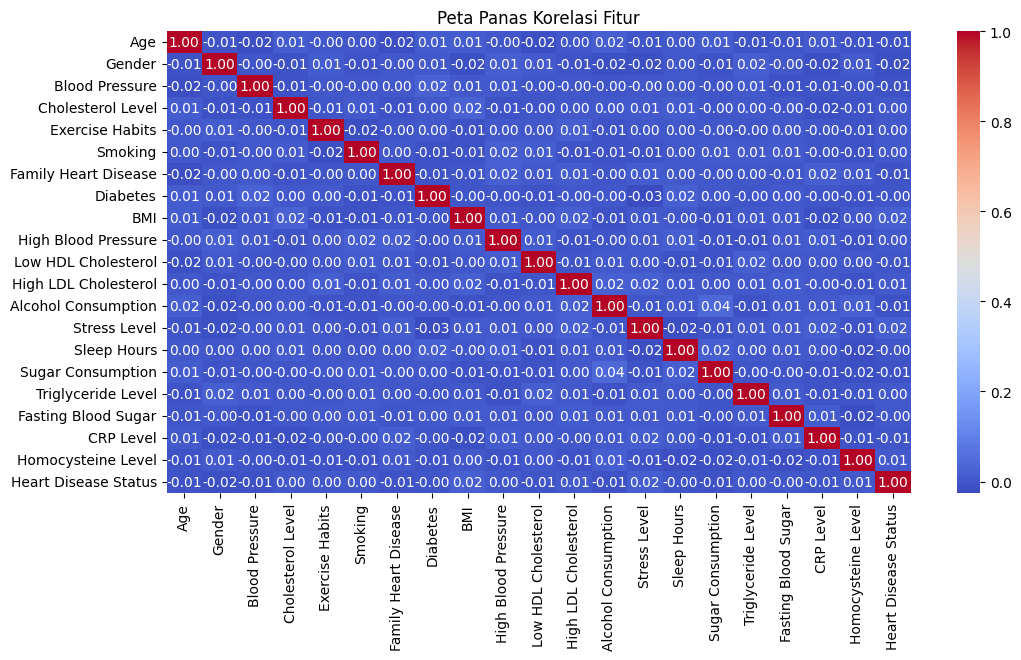

In [12]:
matriks_korelasi = df.corr()

plt.figure(figsize=(12, 6))
sns.heatmap(matriks_korelasi, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Peta Panas Korelasi Fitur")
plt.show()

Menskalakan semua fitur numerik ke rentang [0, 1] menggunakan MinMaxScaler untuk memastikan kontribusi yang sama terhadap pelatihan model. Variabel target (Status Penyakit Jantung) dipertahankan tanpa penskalaan karena merupakan label klasifikasi. Fitur yang telah diskalakan kemudian digabungkan kembali dengan kolom target asli untuk analisis lebih lanjut.

In [13]:
scaler = MinMaxScaler()

Grade_column = df[ 'Heart Disease Status' ]
df_scaled = scaler.fit_transform(df)
df = pd.DataFrame(df_scaled, columns=df.columns)

df[ 'Heart Disease Status' ] = Grade_column

df

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,0.612903,1.0,0.550000,0.033333,0.0,1.0,1.0,0.0,0.317756,1.0,...,0.0,0.0,1.0,0.605503,1.0,0.806667,0.5100,0.864751,0.492507,0.0
1,0.822581,0.0,0.433333,0.906667,0.0,0.0,1.0,1.0,0.328222,0.0,...,0.0,1.0,0.0,0.790657,1.0,0.110000,0.9625,0.623722,0.953319,0.0
2,0.451613,1.0,0.100000,0.440000,0.5,0.0,0.0,0.0,0.538899,0.0,...,1.0,0.5,0.5,0.073314,0.5,0.976667,0.1500,0.847452,0.415412,0.0
3,0.225806,0.0,0.033333,0.953333,0.0,1.0,1.0,0.0,0.278604,1.0,...,1.0,0.5,0.0,0.208156,0.0,0.643333,0.1750,0.834058,0.064120,0.0
4,0.677419,1.0,0.766667,0.613333,0.5,1.0,1.0,1.0,0.112914,1.0,...,0.0,0.5,0.0,0.505116,0.0,0.543333,0.9250,0.692144,0.210260,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.112903,0.0,0.266667,0.620000,1.0,1.0,0.0,0.0,0.035735,1.0,...,1.0,1.0,0.0,0.472443,1.0,0.810000,0.6625,0.239116,0.942193,1.0
9996,0.322581,1.0,0.866667,0.026667,1.0,0.0,0.0,0.0,0.629894,1.0,...,1.0,0.5,0.0,0.707940,0.5,0.923333,0.0375,0.177052,0.314390,1.0
9997,0.887097,1.0,0.533333,0.340000,0.0,1.0,0.0,1.0,0.404521,0.0,...,1.0,0.2,0.5,0.072701,0.5,0.493333,0.1000,0.293810,0.299503,1.0
9998,0.080645,1.0,0.366667,0.993333,0.5,1.0,0.0,1.0,0.771169,1.0,...,1.0,1.0,0.0,0.754369,1.0,0.043333,0.9125,0.481010,0.458253,1.0


Buat diagram batang untuk menggambarkan distribusi variabel target Status Penyakit Jantung.

Heart Disease Status
0.0    8000
1.0    2000
Name: count, dtype: int64


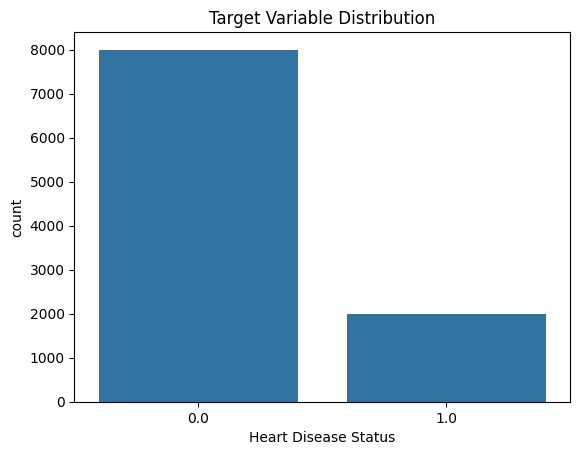

In [14]:
print(df["Heart Disease Status"].value_counts())

sns.countplot(x=df["Heart Disease Status"])
plt.title("Target Variable Distribution")
plt.show()

Kita dapat dengan jelas melihat ketidakseimbangan kelas di mana sebagian besar sampel termasuk dalam kategori tidak sakit (0). Ketidakseimbangan ini dapat menyebabkan model yang bias yang menguntungkan kelas mayoritas, mengurangi kinerja prediksi untuk kelas minoritas (kasus penyakit jantung). Jadi, dengan menggunakan pandas, kami melakukan upsampling manual untuk kelas 1.0. Kami menyeimbangkan data menggunakan duplikasi. Ini memastikan model mempelajari kedua kelas secara setara, meningkatkan akurasi, recall, dan F1-score untuk kelas minoritas. Penyeimbangan data mencegah bias, membuat model lebih andal dan efektif dalam memprediksi kedua kelas.

In [15]:
from sklearn.model_selection import train_test_split

# Pisahkan kelas mayoritas dan minoritas
df_majority = df[df[ 'Heart Disease Status' ] ==  0 ]
df_minority = df[df[ 'Heart Disease Status' ] ==  1 ]

# Tingkatkan jumlah sampel kelas minoritas
df_minority_upsampled = df_minority.sample(n= int ( len (df_majority) *  0.5 ), replace= True , random_state= 42 )

# Gabungkan keduanya
df_balanced = pd.concat([df_majority, df_minority_upsampled ])

# Acak dataset
df_balanced = df_balanced.sample(frac= 1 , random_state= 42 )

# Pisahkan menjadi fitur dan label
X = df_balanced.drop(columns=[ 'Heart Disease Status' ])
y = df_balanced[ 'Heart Disease Status' ]

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size= 0.2 , random_state= 42 )

In [16]:
# Menyimpan data preprocessing ke dalam csv
df.to_csv('heart_disease_preprocessed.csv', index=False)
print('Data berhasil disimpan !')

Data berhasil disimpan !
